<a href="https://colab.research.google.com/github/gomathijss-create/FUTURE_DS_01/blob/main/Business_Sales_Performance_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Business Sales Performance Analytics**

# **Project Objective**

To analyze business sales data and identify sales trends, profitable categories, regional performance, and loss-making products in order to support data-driven business decisions and recommend growth strategies.

# **Problem Statement**

The business aims to understand its sales performance and address the following key questions:

1. Which products and categories generate the highest revenue and profit?
2. How have sales and profits changed over time?
3. Which regions contribute the most to business growth?
4. Which products or sub-categories are causing losses?
5. What strategies can be implemented to improve profitability and accelerate business growth?

# **Initial EDA**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel("https://github.com/gomathijss-create/FUTURE_DS_01/raw/refs/heads/main/Superstore%20analysis%20Excel.xlsx")
df

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11-08-2016,11-11-2016,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,CA-2016-152156,11-08-2016,11-11-2016,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,CA-2016-138688,06-12-2016,6/16/2016,DV-13045,Darrin Van Huff,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,US-2015-108966,10-11-2015,10/18/2015,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,US-2015-108966,10-11-2015,10/18/2015,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,1/21/2014,1/23/2014,TB-21400,Tom Boeckenhauer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,CA-2017-121258,2/26/2017,03-03-2017,DB-13060,Dave Brooks,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,CA-2017-121258,2/26/2017,03-03-2017,DB-13060,Dave Brooks,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,258.5760,2,0.20,19.3932
9992,CA-2017-121258,2/26/2017,03-03-2017,DB-13060,Dave Brooks,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [ ]:
df.shape

(9994, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Customer ID    9994 non-null   object 
 4   Customer Name  9994 non-null   object 
 5   Country        9994 non-null   object 
 6   City           9994 non-null   object 
 7   State          9994 non-null   object 
 8   Postal Code    9994 non-null   int64  
 9   Region         9994 non-null   object 
 10  Product ID     9994 non-null   object 
 11  Category       9994 non-null   object 
 12  Sub-Category   9994 non-null   object 
 13  Sales          9994 non-null   float64
 14  Quantity       9994 non-null   int64  
 15  Discount       9994 non-null   float64
 16  Profit         9994 non-null   float64
dtypes: float64(3), int64(2), object(12)
memory usage: 1.

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# **Data cleaning and pre-processing**

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(9993, 17)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format = 'mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format = 'mixed')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9993 non-null   object        
 1   Order Date     9993 non-null   datetime64[ns]
 2   Ship Date      9993 non-null   datetime64[ns]
 3   Customer ID    9993 non-null   object        
 4   Customer Name  9993 non-null   object        
 5   Country        9993 non-null   object        
 6   City           9993 non-null   object        
 7   State          9993 non-null   object        
 8   Postal Code    9993 non-null   int64         
 9   Region         9993 non-null   object        
 10  Product ID     9993 non-null   object        
 11  Category       9993 non-null   object        
 12  Sub-Category   9993 non-null   object        
 13  Sales          9993 non-null   float64       
 14  Quantity       9993 non-null   int64         
 15  Discount       9993 non-nu

In [ ]:
# Year
df['Year'] = df['Order Date'].dt.year

# Month Name
df['Month'] = df['Order Date'].dt.month_name()

# Month Number (for sorting)
df['Month Number'] = df['Order Date'].dt.month

# Quarter
df['Quarter'] = df['Order Date'].dt.quarter

# Profit Margin %
df['Profit Margin %'] = (
    df['Profit']/df['Sales']
)*100

In [ ]:
df.head(5)

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Country,City,State,Postal Code,Region,...,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Month Number,Quarter,Profit Margin %
0,CA-2016-152156,2016-11-08,2016-11-11,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,South,...,Bookcases,261.9600,2,0.00,41.9136,2016,November,11,4,16.00
1,CA-2016-152156,2016-11-08,2016-11-11,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,South,...,Chairs,731.9400,3,0.00,219.5820,2016,November,11,4,30.00
2,CA-2016-138688,2016-06-12,2016-06-16,DV-13045,Darrin Van Huff,United States,Los Angeles,California,90036,West,...,Labels,14.6200,2,0.00,6.8714,2016,June,6,2,47.00
3,US-2015-108966,2015-10-11,2015-10-18,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311,South,...,Tables,957.5775,5,0.45,-383.0310,2015,October,10,4,-40.00
4,US-2015-108966,2015-10-11,2015-10-18,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311,South,...,Storage,22.3680,2,0.20,2.5164,2015,October,10,4,11.25


# **Exploratory Data Analysis and Visualization**

# **Overall Sales KPI**

In [ ]:
total_sales = df['Sales'].sum().round(2)

total_profit = df['Profit'].sum().round(2)

total_orders = df['Order ID'].nunique()

total_customers = df['Customer ID'].nunique()

print("Total Sales :", total_sales)
print("Total Profit :", total_profit)
print("Total Orders :", total_orders)
print("Total Customers :", total_customers)

Total Sales : 2296919.49
Total Profit : 286409.08
Total Orders : 5009
Total Customers : 793


# **Sales Trend Over Time**

In [ ]:
sales_trend = (
    df.groupby('Year')['Sales']
    .sum()
    .reset_index()
)

sales_trend

,Year,Sales
0,2014,483966.1261
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


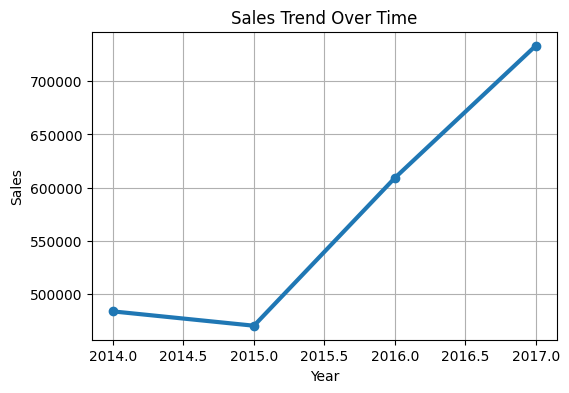

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    sales_trend['Year'],
    sales_trend['Sales'],
    marker='o',
    linewidth = 3
)

plt.title('Sales Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.grid(True)

plt.show()

# **Interpretation**
Sales showed a consistent upward trend from 2015 to 2017, with the highest sales recorded in 2017 ($733K), indicating steady business growth.

# **Sales by Category**

In [ ]:
category_sales = (
    df.groupby('Category')
    ['Sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741718.4233
Office Supplies,719047.0320


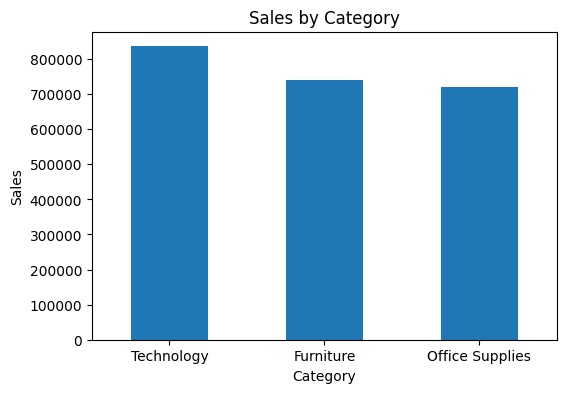

In [ ]:
category_sales.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Sales by Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

# **Interpretation**
Technology category generated the highest sales ($836K) making it the strongest performing business segment.

# **Profit by Category**





In [ ]:
category_profit = (
    df.groupby('Category')
    ['Profit']
    .sum()
    .sort_values(ascending=False)
)

category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18463.3316


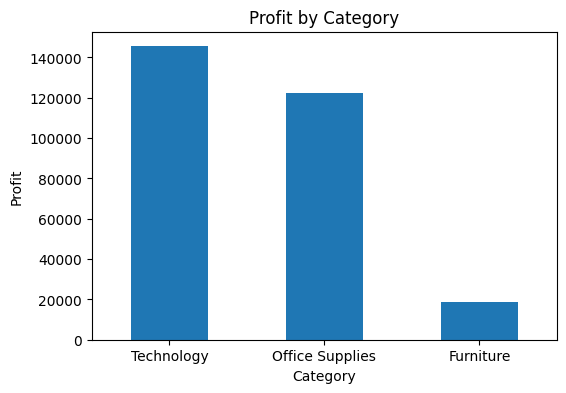

In [ ]:
category_profit.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Profit by Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.show()

# **Interpretation**

Technology category generated the highest sales ($836K) and profit(145K) making it the strongest performing business segment.

# **Sales by Region**

In [ ]:
region_sales = (
    df.groupby('Region')
    ['Sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,725457.8245
East,678499.8680
Central,501239.8908
South,391721.9050


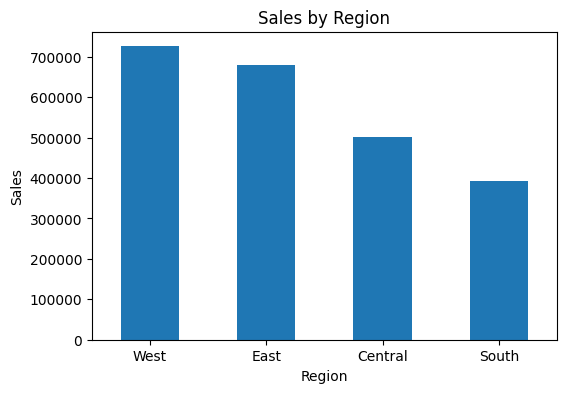

In [ ]:
region_sales.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Sales by Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

# **Profit by Region**

In [ ]:
region_profit = (
    df.groupby('Region')
    ['Profit']
    .sum()
    .sort_values(ascending=False)
)

region_profit

,Profit
Region,
West,108418.4489
East,91534.8388
South,46749.4303
Central,39706.3625


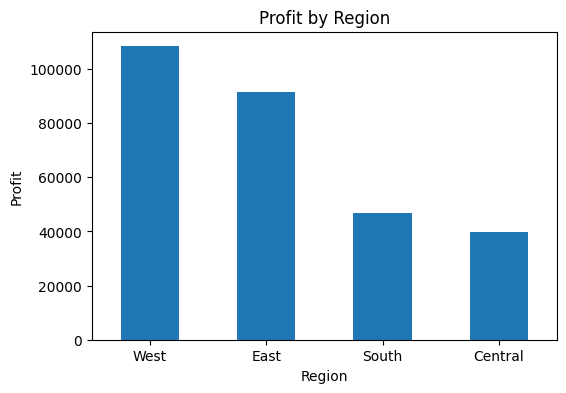

In [ ]:
region_profit.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Profit by Region')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.show()

# **Interpretation**

The West region contributed the highest sales (725K) and profit (108K), making it the most profitable geographical market.

# **Top 10 Sub-category by Sales**

In [ ]:
top_products = (
    df.groupby('Sub-Category')
    ['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328167.7310
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


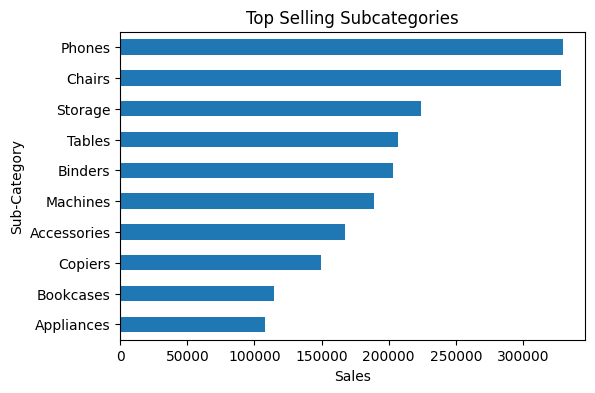

In [ ]:
top_products.sort_values().plot(
    kind='barh',
    figsize=(6,4)
)

plt.title('Top Selling Subcategories')
plt.xlabel('Sales')

plt.show()

# **Interpretation**

Phones, Chairs, and Storage emerged as the top revenue-generating sub-categories, significantly contributing to overall business performance.

# **Sub-Categories causing losses**

In [ ]:
loss_subcategory = (
    df.groupby('Sub-Category')['Profit']
    .sum()
)

loss_subcategory = loss_subcategory[
    loss_subcategory < 0
].sort_values()

loss_subcategory

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995


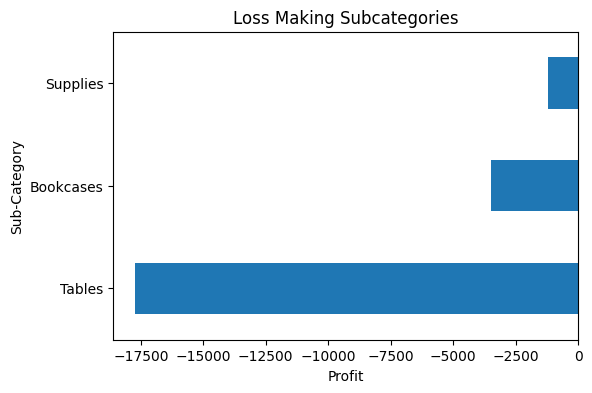

In [ ]:
loss_subcategory.plot(
    kind='barh',
    figsize=(6,4)
)

plt.title('Loss Making Subcategories')
plt.xlabel('Profit')

plt.show()

# **Interpretation**
Tables, Bookcases, and Supplies were identified as loss-making sub-categories, with Tables generating the highest loss (-$17.7K).



# **Insights**
1. Technology category generated the highest sales (USD 836K ) and profit (USD 145K ), making it the strongest performing business segment.

2. Sales showed a consistent upward trend from 2015 to 2017, with the highest sales recorded in 2017 (USD 733K), indicating steady business growth.

3. The West region contributed the highest sales (USD 725K) and profit (USD 108K), making it the most profitable geographical market.

4. Phones, Chairs, and Storage emerged as the top revenue-generating sub-categories, significantly contributing to overall business performance.

5. Tables, Bookcases, and Supplies were identified as loss-making sub-categories, with Tables generating the highest loss (USD -17.7K).

# **Recommendations**
1.Increase investment and marketing efforts in Technology products to maximize revenue and profitability.

2.Focus on expanding operations and customer acquisition strategies in the West region while replicating its successful practices in other regions.

3.Review pricing strategies, discount policies, and supply chain costs for Tables and Bookcases to reduce losses.

4.Optimize Furniture category profitability through better cost management and discount control, as it generates high sales but relatively low profit.

5.Maintain sufficient inventory and promotional campaigns for high-performing products such as Phones, Chairs, and Storage to sustain business growth.

# **Downloading cleaned data for dashboard creation using Power BI**

In [ ]:
df.to_csv('cleaned_ecommerce_sales.csv',index=False)

# **Dashboard**

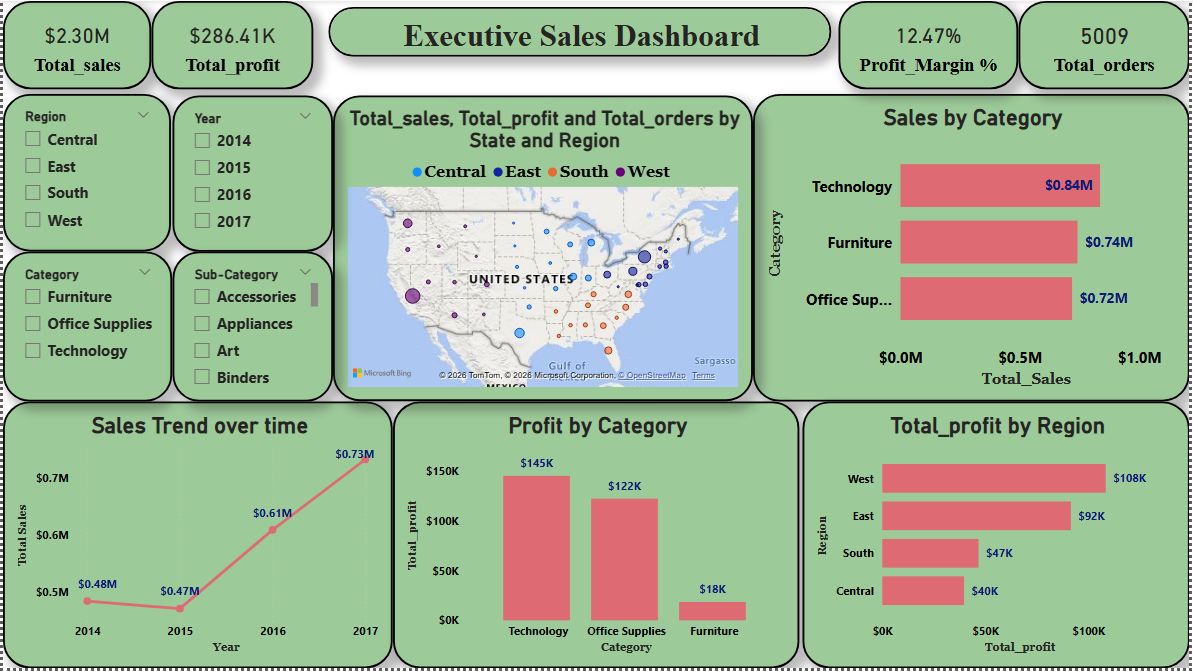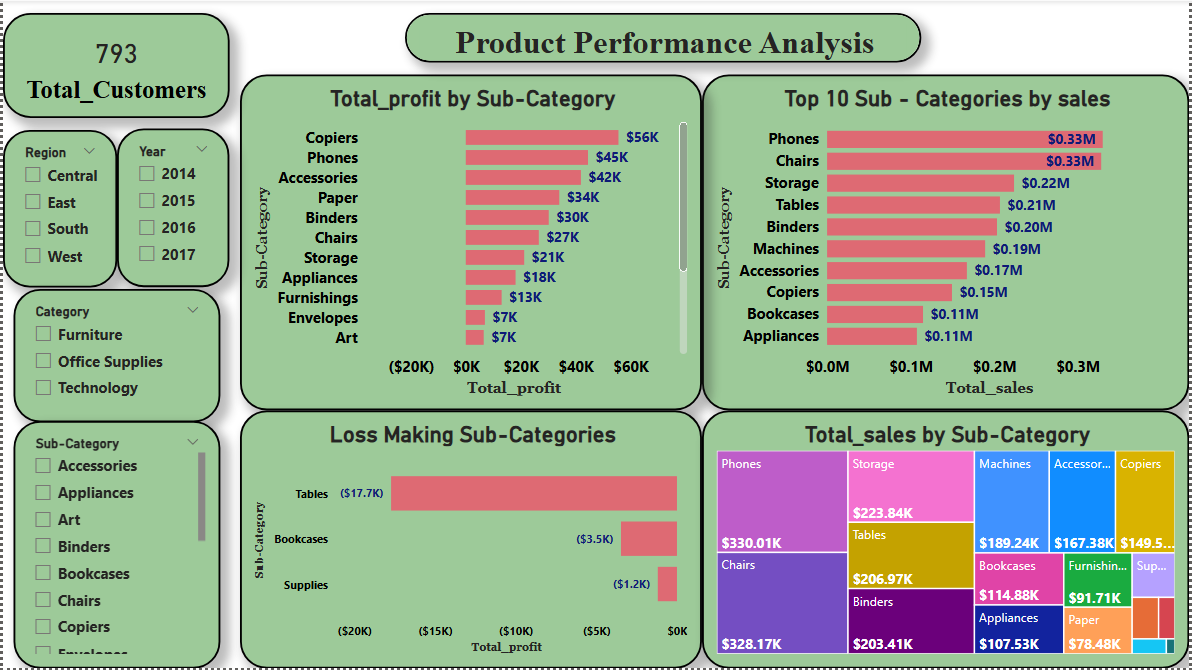

# **Conclusion**
The business demonstrates strong growth potential with increasing sales trends and high-performing Technology products. However, loss-making sub-categories such as Tables and Bookcases require strategic attention. Implementing data-driven decisions can help improve profitability and support sustainable business growth.